# nnU-Net Results Preview for ARCADE

Preview nnU-Net framework predictions for ARCADE using class-ID masks. The notebook can optionally run inference from a checkpoint first, then visualize raw image, ground truth, prediction, confusion overlays, and calculate pixel and boundary metrics.


In [ ]:
# Imports and paths
from __future__ import annotations

import os
import re
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from PIL import Image

try:
    import cv2
except Exception:
    cv2 = None

try:
    from skimage.morphology import skeletonize
except Exception:
    skeletonize = None

REPO_ROOT = Path.cwd()
if (REPO_ROOT / "lightm-unet").exists():
    PACKAGE_ROOT = REPO_ROOT / "lightm-unet"
else:
    PACKAGE_ROOT = REPO_ROOT

DATASET_NAME = "Dataset501_ARCADE"
DATASET_ID = "501"
CONFIGURATION = "2d"
PLANS_NAME = "nnUNetPlans"
FOLD = 0

DATASET_DIR = REPO_ROOT / "data" / "nnUNet_raw" / DATASET_NAME
IMAGES_TS_DIR = DATASET_DIR / "imagesTs"
LABELS_TS_DIR = DATASET_DIR / "labelsTs"
NNUNET_PREPROCESSED = REPO_ROOT / "data" / "nnUNet_preprocessed"
NNUNET_RESULTS = REPO_ROOT / "data" / "nnUNET_results"

NET_NAME = "ENetUpscaleSkipD2"
TRAINER_NAME = "nnUNetTrainerENetSkip"
CHECKPOINT_PATH = NNUNET_RESULTS / DATASET_NAME / f"{TRAINER_NAME}__{PLANS_NAME}__{CONFIGURATION}" / f"fold_{FOLD}" / "checkpoint_best.pth"
CHECKPOINT_NAME = CHECKPOINT_PATH.name
PREDICTION_DIR = DATASET_DIR / f"labelsPr_{NET_NAME}"
LEGACY_PREDICTED_DIR = DATASET_DIR / "predicted"

N_CLASSES = 4
CLASS_LABELS = ["Background", "LAD", "RCA", "LCX"]
CLASS_COLORS = ["#000000", "#e6194b", "#3cb44b", "#4363d8"]
CMAP = mcolors.ListedColormap(CLASS_COLORS)
NORM = mcolors.BoundaryNorm(range(N_CLASSES + 1), N_CLASSES)
IMSHOW_MASK_KW = dict(cmap=CMAP, norm=NORM, interpolation="nearest")
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

print("Repo root       :", REPO_ROOT)
print("Package root    :", PACKAGE_ROOT)
print("Dataset dir     :", DATASET_DIR)
print("ImagesTs        :", IMAGES_TS_DIR)
print("LabelsTs        :", LABELS_TS_DIR)
print("Prediction dir  :", PREDICTION_DIR)
print("Checkpoint      :", CHECKPOINT_PATH)


Repo root       : /workspace/LightM-UNet
Package root    : /workspace/LightM-UNet/lightm-unet
Dataset dir     : /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE
ImagesTs        : /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/imagesTs
LabelsTs        : /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/labelsTs
Prediction dir  : /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/labelsPr_ENetUpscaleSkipD1
Checkpoint      : /workspace/LightM-UNet/data/nnUNET_results/Dataset501_ARCADE/nnUNetTrainerENetSkip__nnUNetPlans__2d/fold_0/checkpoint_best.pth


## Optional: Run Inference From a Checkpoint

This cell runs nnU-Net inference on `imagesTs` and writes class-ID predictions to `labelsPr_[NETNAME]`. It also adopts an existing `predicted/` directory by renaming it to `labelsPr_[NETNAME]` when appropriate.


In [38]:
# Inference block
RUN_INFERENCE = True          # Set True to generate predictions from CHECKPOINT_PATH
OVERWRITE_PREDICTIONS = True  # Set True to replace existing labelsPr_[NETNAME]
DEVICE = "cuda"               # "cuda" or "cpu"
DISABLE_TTA = True             # Faster previews; set False for nnU-Net default mirroring TTA
NUM_PREPROCESS_WORKERS = 2
NUM_EXPORT_WORKERS = 2


def adopt_legacy_predicted_folder() -> None:
    if not LEGACY_PREDICTED_DIR.exists():
        return
    legacy_files = [p for p in LEGACY_PREDICTED_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if not legacy_files:
        print(f"Legacy folder exists but has no prediction masks: {LEGACY_PREDICTED_DIR}")
        return
    if not PREDICTION_DIR.exists():
        LEGACY_PREDICTED_DIR.rename(PREDICTION_DIR)
        print(f"Renamed {LEGACY_PREDICTED_DIR} -> {PREDICTION_DIR}")
    else:
        print(f"Keeping {PREDICTION_DIR}; legacy folder also exists at {LEGACY_PREDICTED_DIR}")


def infer_trainer_from_checkpoint(checkpoint: Path) -> str:
    model_folder = checkpoint.parents[1]
    return model_folder.name.split("__", 1)[0] if "__" in model_folder.name else TRAINER_NAME


def run_nnunet_inference() -> None:
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
    if not IMAGES_TS_DIR.exists():
        raise FileNotFoundError(f"imagesTs not found: {IMAGES_TS_DIR}")

    if PREDICTION_DIR.exists() and OVERWRITE_PREDICTIONS:
        shutil.rmtree(PREDICTION_DIR)
    PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

    trainer = infer_trainer_from_checkpoint(CHECKPOINT_PATH)
    os.environ["nnUNet_raw"] = str(REPO_ROOT / "data" / "nnUNet_raw")
    os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
    os.environ["nnUNet_results"] = str(NNUNET_RESULTS)

    command = [
        shutil.which("nnUNetv2_predict") or "nnUNetv2_predict",
        "-i", str(IMAGES_TS_DIR),
        "-o", str(PREDICTION_DIR),
        "-d", DATASET_ID,
        "-c", CONFIGURATION,
        "-tr", trainer,
        "-p", PLANS_NAME,
        "-f", str(FOLD),
        "-chk", CHECKPOINT_NAME,
        "-device", DEVICE,
        "-npp", str(NUM_PREPROCESS_WORKERS),
        "-nps", str(NUM_EXPORT_WORKERS),
        "--disable_progress_bar",
    ]
    if DISABLE_TTA:
        command.append("--disable_tta")

    print("Running:", " ".join(command))
    completed = subprocess.run(command, cwd=PACKAGE_ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(f"nnU-Net inference failed with return code {completed.returncode}")

adopt_legacy_predicted_folder()
if RUN_INFERENCE:
    run_nnunet_inference()
else:
    print("RUN_INFERENCE=False; using existing predictions if present.")


Legacy folder exists but has no prediction masks: /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/predicted
Running: /opt/conda/bin/nnUNetv2_predict -i /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/imagesTs -o /workspace/LightM-UNet/data/nnUNet_raw/Dataset501_ARCADE/labelsPr_ENetUpscaleSkipD1 -d 501 -c 2d -tr nnUNetTrainerENetSkip -p nnUNetPlans -f 0 -chk checkpoint_best.pth -device cuda -npp 2 -nps 2 --disable_progress_bar --disable_tta

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/opt/conda/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setu

## Build Sample Index

In [39]:
# Match imagesTs, labelsTs, and labelsPr_[NETNAME] by case ID.
def case_id_from_image(path: Path) -> str:
    stem = path.stem
    return stem[:-5] if stem.endswith("_0000") else stem


def image_files(folder: Path) -> list[Path]:
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)

img_files = image_files(IMAGES_TS_DIR)
gt_files = {p.stem: p for p in image_files(LABELS_TS_DIR)}
pred_files = {p.stem: p for p in image_files(PREDICTION_DIR)} if PREDICTION_DIR.exists() else {}

samples = []
for img in img_files:
    cid = case_id_from_image(img)
    if cid in gt_files and cid in pred_files:
        samples.append({"case_id": cid, "image": img, "gt": gt_files[cid], "pred": pred_files[cid]})

print(f"ImagesTs found  : {len(img_files)}")
print(f"LabelsTs found  : {len(gt_files)}")
print(f"Predictions found: {len(pred_files)}")
print(f"Matched samples : {len(samples)}")

if not samples:
    raise FileNotFoundError(
        "No matched samples found. Run inference first or check PREDICTION_DIR.\n"
        f"ImagesTs: {IMAGES_TS_DIR}\nLabelsTs: {LABELS_TS_DIR}\nPredictions: {PREDICTION_DIR}"
    )


ImagesTs found  : 300
LabelsTs found  : 300
Predictions found: 300
Matched samples : 300


## Loading Helpers

In [40]:
def load_class_id_mask(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        # Defensive fallback only: this framework should write class-ID masks, not RGB masks.
        arr = arr[..., 0]
    return arr.astype(np.uint8)


def resize_mask_to(mask: np.ndarray, shape_hw: tuple[int, int]) -> np.ndarray:
    target_h, target_w = shape_hw
    if mask.shape == (target_h, target_w):
        return mask
    return np.asarray(Image.fromarray(mask).resize((target_w, target_h), Image.NEAREST), dtype=np.uint8)


def load_sample(idx: int):
    item = samples[idx]
    raw = np.asarray(Image.open(item["image"]).convert("L"), dtype=np.float32) / 255.0
    gt = load_class_id_mask(item["gt"])
    pred = load_class_id_mask(item["pred"])
    pred = resize_mask_to(pred, gt.shape)
    raw_display = raw
    if raw_display.shape != gt.shape:
        raw_display = np.asarray(Image.fromarray((raw_display * 255).astype(np.uint8)).resize((gt.shape[1], gt.shape[0]), Image.BICUBIC), dtype=np.float32) / 255.0
    return raw_display, gt, pred


def legend_handles():
    return [mpatches.Patch(color=CLASS_COLORS[i], label=f"{i}: {CLASS_LABELS[i]}") for i in range(N_CLASSES)]


## Preview: Raw Image, Ground Truth, Prediction

In [41]:
def show_sample(idx: int, ax_row=None, save_path: Path | None = None):
    raw, gt, pred = load_sample(idx)
    standalone = ax_row is None
    if standalone:
        fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    else:
        axes = ax_row
        fig = axes[0].figure

    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Raw")
    axes[0].axis("off")

    axes[1].imshow(gt, **IMSHOW_MASK_KW)
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(pred, **IMSHOW_MASK_KW)
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    if standalone:
        fig.legend(handles=legend_handles(), loc="lower center", ncol=N_CLASSES, bbox_to_anchor=(0.5, -0.04), frameon=False)
        fig.suptitle(f"{idx}: {samples[idx]['case_id']}", fontsize=13, fontweight="bold")
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, bbox_inches="tight", dpi=150)
        plt.show()


def show_batch(indices=None, n_samples: int = 6, save_path: Path | None = None):
    if indices is None:
        indices = list(range(min(n_samples, len(samples))))
    indices = list(indices)
    fig, axes = plt.subplots(len(indices), 3, figsize=(14, 4.2 * len(indices)))
    axes = np.atleast_2d(axes)
    for row, idx in enumerate(indices):
        show_sample(idx, ax_row=axes[row])
        axes[row][0].set_ylabel(samples[idx]["case_id"], fontsize=9, rotation=90, labelpad=8)
    fig.legend(handles=legend_handles(), loc="lower center", ncol=N_CLASSES, bbox_to_anchor=(0.5, -0.01), frameon=False)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

# show_batch(n_samples=50)


## Confusion Overlay

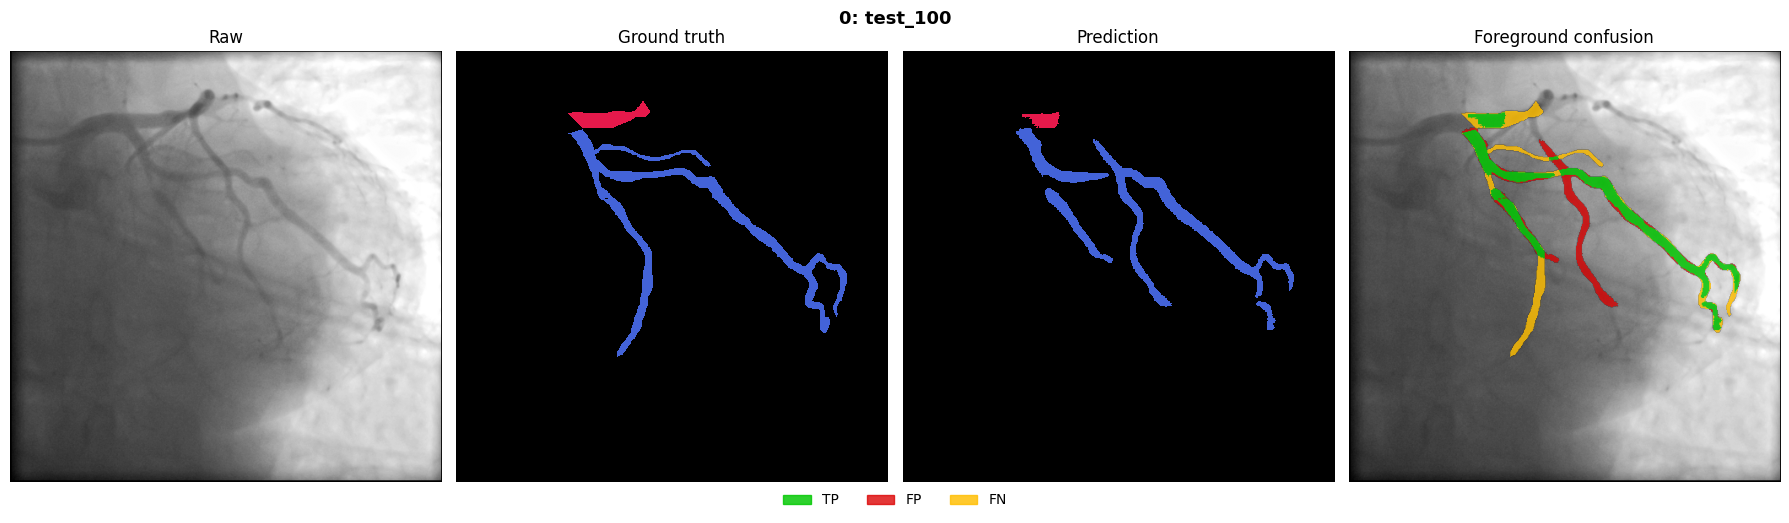

In [42]:
CONFUSION_COLORS = {
    "TP": np.array([0, 200, 0, 210], dtype=np.uint8),
    "FP": np.array([220, 0, 0, 200], dtype=np.uint8),
    "FN": np.array([255, 190, 0, 210], dtype=np.uint8),
    "TN": np.array([0, 0, 0, 0], dtype=np.uint8),
}


def make_foreground_confusion(gt: np.ndarray, pred: np.ndarray) -> np.ndarray:
    gt_fg = gt > 0
    pred_fg = pred > 0
    overlay = np.zeros((*gt.shape, 4), dtype=np.uint8)
    overlay[(gt_fg & pred_fg)] = CONFUSION_COLORS["TP"]
    overlay[(~gt_fg & pred_fg)] = CONFUSION_COLORS["FP"]
    overlay[(gt_fg & ~pred_fg)] = CONFUSION_COLORS["FN"]
    return overlay


def show_confusion(idx: int, save_path: Path | None = None):
    raw, gt, pred = load_sample(idx)
    overlay = make_foreground_confusion(gt, pred)
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(raw, cmap="gray"); axes[0].set_title("Raw"); axes[0].axis("off")
    axes[1].imshow(gt, **IMSHOW_MASK_KW); axes[1].set_title("Ground truth"); axes[1].axis("off")
    axes[2].imshow(pred, **IMSHOW_MASK_KW); axes[2].set_title("Prediction"); axes[2].axis("off")
    axes[3].imshow(raw, cmap="gray"); axes[3].imshow(overlay); axes[3].set_title("Foreground confusion"); axes[3].axis("off")
    handles = [
        mpatches.Patch(color=CONFUSION_COLORS["TP"] / 255, label="TP"),
        mpatches.Patch(color=CONFUSION_COLORS["FP"] / 255, label="FP"),
        mpatches.Patch(color=CONFUSION_COLORS["FN"] / 255, label="FN"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), frameon=False)
    fig.suptitle(f"{idx}: {samples[idx]['case_id']}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

show_confusion(0)


Saved: preview_metrics/ENetUpscaleSkipD1_confusion_grid_display.png


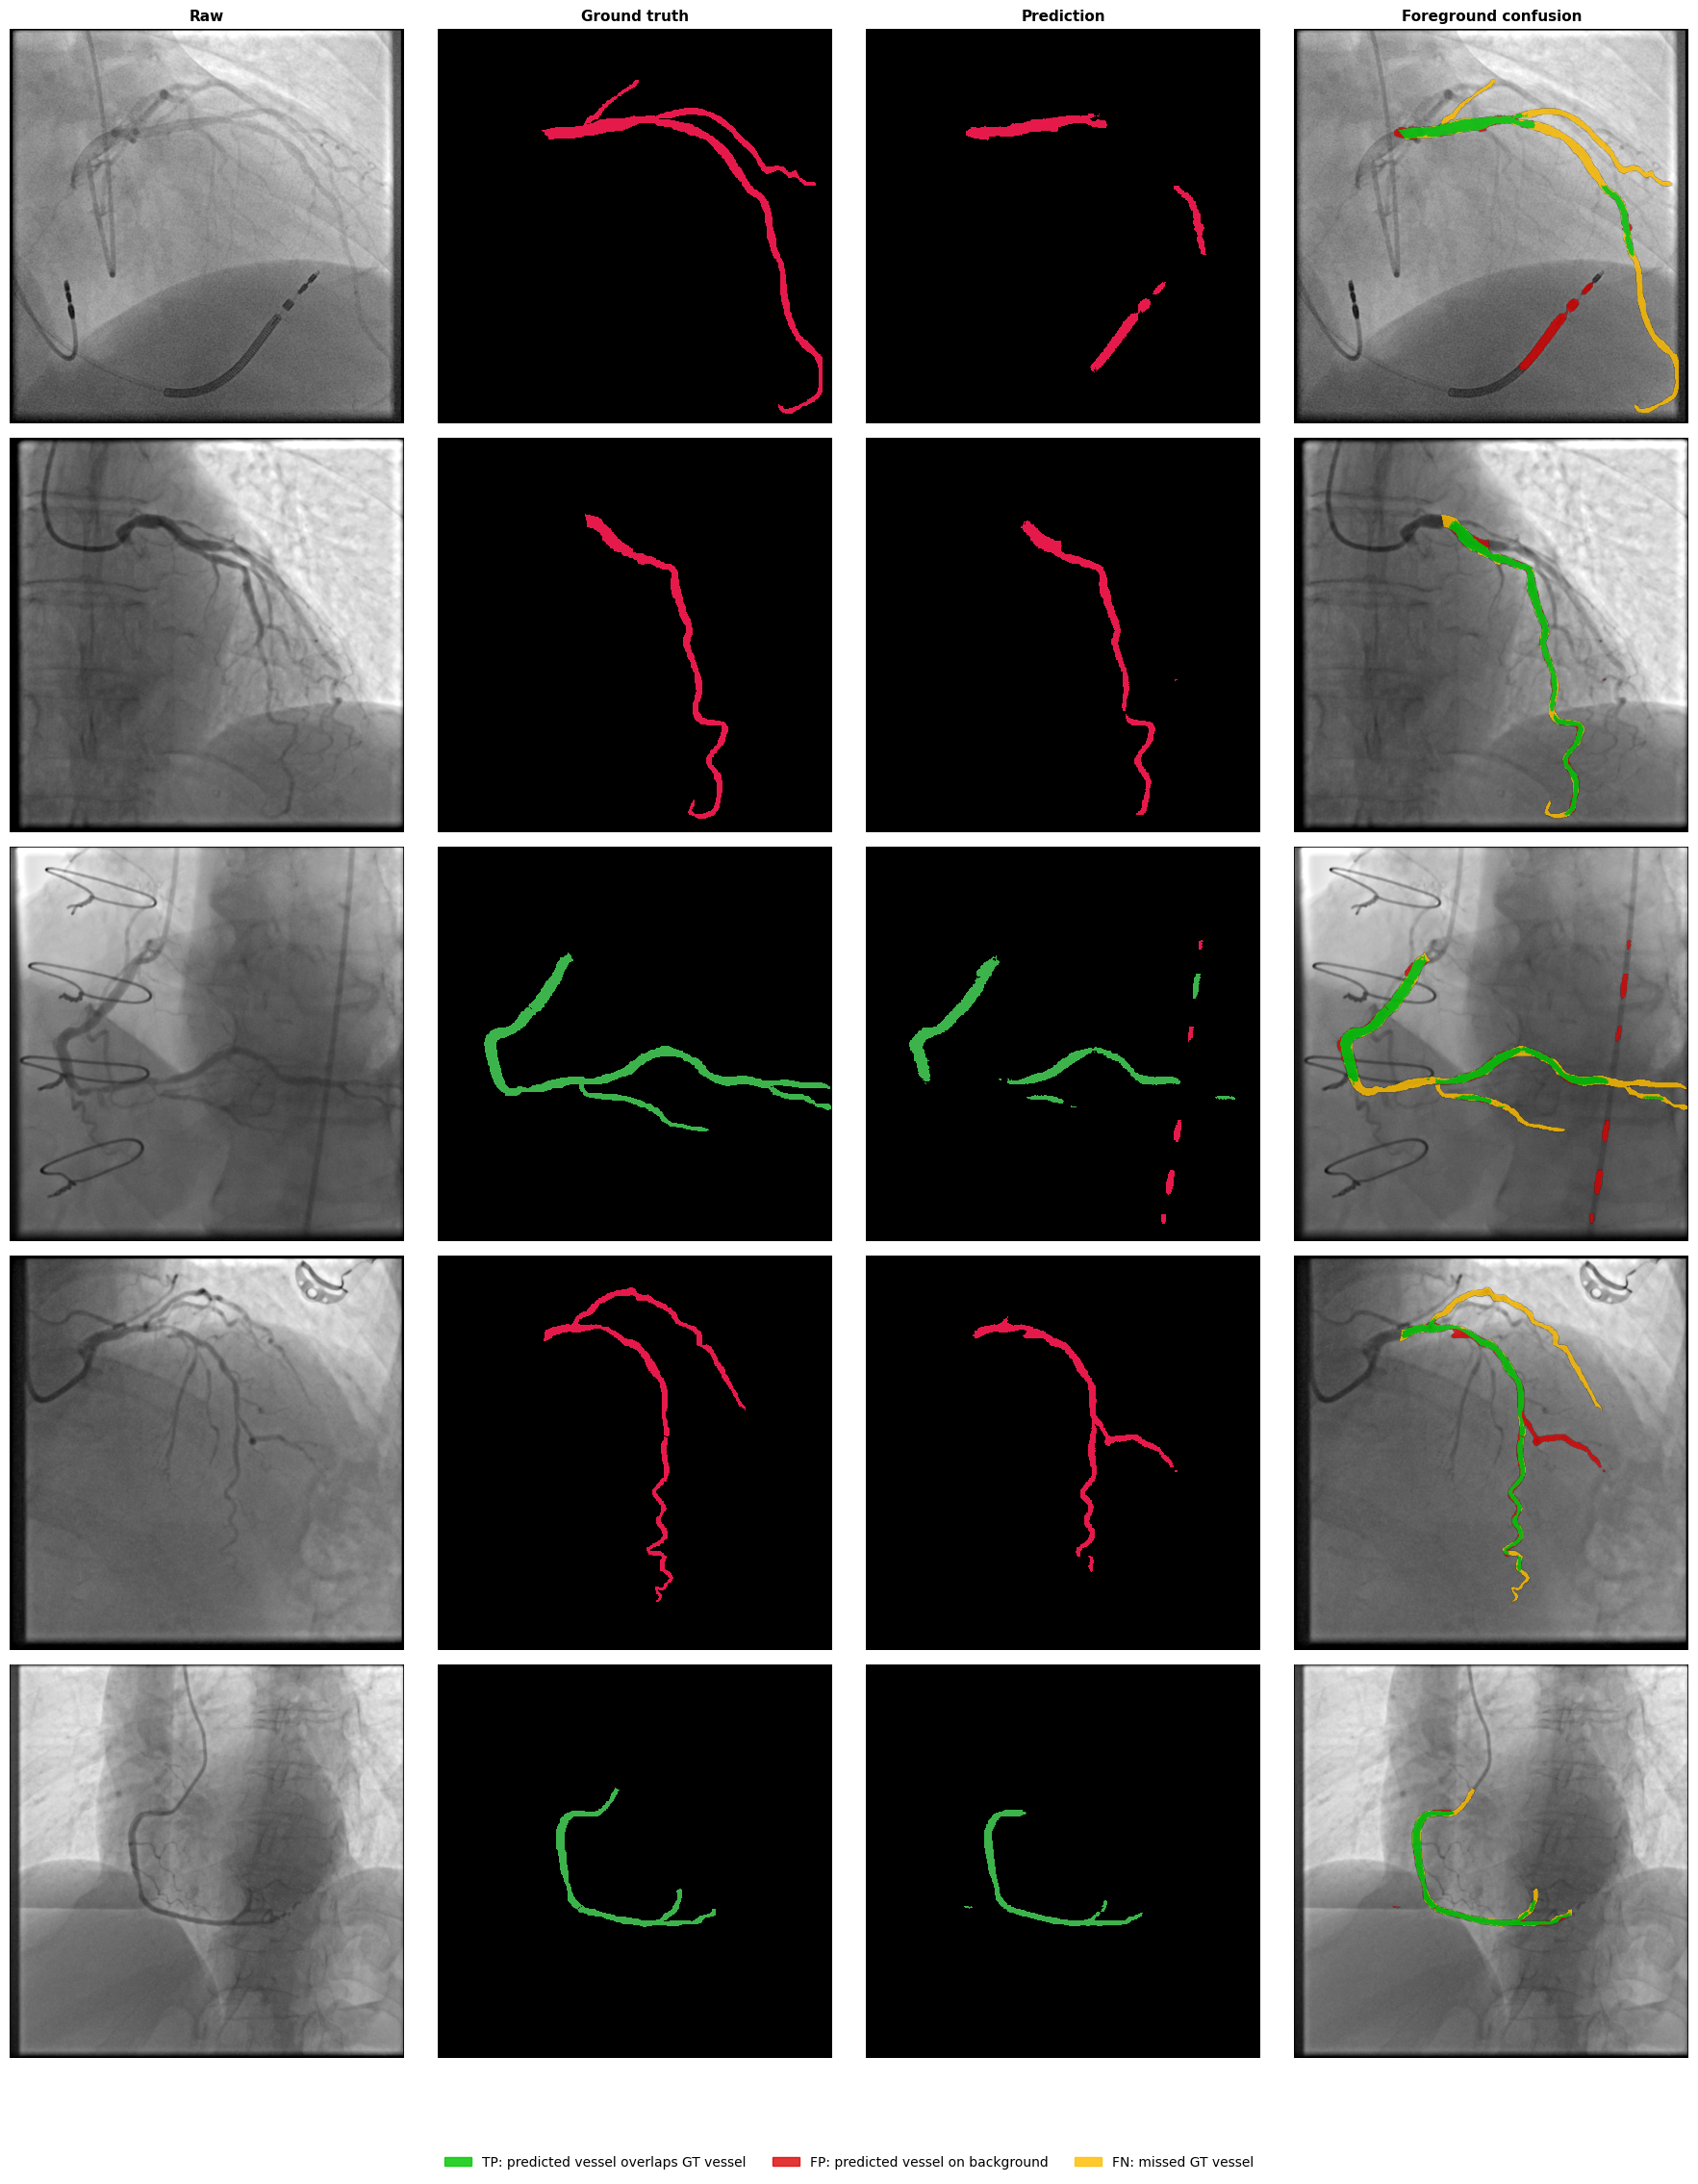

In [43]:
# Batch confusion grid
# from matplotlib import patches as mpatches

CONFUSION_LEGEND = [
    mpatches.Patch(color=CONFUSION_COLORS["TP"] / 255, label="TP: predicted vessel overlaps GT vessel"),
    mpatches.Patch(color=CONFUSION_COLORS["FP"] / 255, label="FP: predicted vessel on background"),
    mpatches.Patch(color=CONFUSION_COLORS["FN"] / 255, label="FN: missed GT vessel"),
]


def _confusion_grid(indices, save_path: Path | None = None):
    """Render raw image, GT, prediction, and foreground confusion for sample indices."""
    indices = list(indices)
    if not indices:
        print("No samples to display.")
        return

    fig, axes = plt.subplots(len(indices), 4, figsize=(18, 4.5 * len(indices)))
    axes = np.atleast_2d(axes)

    for col, title in enumerate(["Raw", "Ground truth", "Prediction", "Foreground confusion"]):
        axes[0, col].set_title(title, fontsize=11, fontweight="bold")

    for row, idx in enumerate(indices):
        raw, gt, pred = load_sample(idx)
        confusion = make_foreground_confusion(gt, pred)
        case_id = samples[idx]["case_id"]

        axes[row, 0].imshow(raw, cmap="gray")
        axes[row, 0].set_ylabel(f"#{idx}\n{case_id}", fontsize=8, rotation=0, labelpad=34, va="center")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt, **IMSHOW_MASK_KW)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred, **IMSHOW_MASK_KW)
        axes[row, 2].axis("off")

        axes[row, 3].imshow(raw, cmap="gray")
        axes[row, 3].imshow(confusion)
        axes[row, 3].axis("off")

    fig.legend(handles=CONFUSION_LEGEND, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01), frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved: {save_path}")
    plt.show()


def show_confusion_batch(n_samples: int = 6, save_path: Path | None = None):
    """Show the first n_samples matched test cases."""
    n_samples = min(n_samples, len(samples))
    _confusion_grid(range(n_samples), save_path=save_path)


def show_confusion_indices(indices, save_path: Path | None = None):
    """Show specific sample indices, for example [0, 12, 25]."""
    _confusion_grid(indices, save_path=save_path)

# show_confusion_indices([i for i in range(0, 25)], save_path=Path("preview_metrics/PUNET_confusion_grid_display.png"))
show_confusion_indices([3, 8, 15, 22, 24], save_path=Path("preview_metrics/%s_confusion_grid_display.png" % NET_NAME))

## Metrics: Dice/F1, Precision, Recall/Sensitivity, Boundary F1, clDice

In [44]:
EPS = 1e-8


def binary_counts(gt_bool: np.ndarray, pred_bool: np.ndarray) -> tuple[int, int, int]:
    tp = int((gt_bool & pred_bool).sum())
    fp = int((~gt_bool & pred_bool).sum())
    fn = int((gt_bool & ~pred_bool).sum())
    return tp, fp, fn


def prf_from_counts(tp: int, fp: int, fn: int) -> dict[str, float]:
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    dice = (2 * tp) / (2 * tp + fp + fn + EPS)
    return {"dice_f1": dice, "precision": precision, "recall_sensitivity": recall}


def mask_boundary(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if cv2 is not None:
        kernel = np.ones((3, 3), dtype=np.uint8)
        eroded = cv2.erode(mask.astype(np.uint8), kernel, iterations=1).astype(bool)
        return mask & ~eroded
    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    neighbors_all = np.ones_like(mask, dtype=bool)
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            neighbors_all &= padded[1 + dy:1 + dy + mask.shape[0], 1 + dx:1 + dx + mask.shape[1]]
    return mask & ~neighbors_all


def dilate_binary(mask: np.ndarray, radius: int) -> np.ndarray:
    mask = mask.astype(bool)
    if radius <= 0:
        return mask
    if cv2 is not None:
        kernel = np.ones((2 * radius + 1, 2 * radius + 1), dtype=np.uint8)
        return cv2.dilate(mask.astype(np.uint8), kernel, iterations=1).astype(bool)
    out = mask.copy()
    padded = np.pad(mask, radius, mode="constant", constant_values=False)
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            out |= padded[radius + dy:radius + dy + mask.shape[0], radius + dx:radius + dx + mask.shape[1]]
    return out


def binary_skeleton(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if not mask.any():
        return mask
    if skeletonize is not None:
        return skeletonize(mask).astype(bool)

    # Morphological skeleton fallback for environments without scikit-image.
    if cv2 is not None:
        work = mask.astype(np.uint8)
        skel = np.zeros_like(work, dtype=np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
        while work.any():
            eroded = cv2.erode(work, kernel)
            opened = cv2.dilate(eroded, kernel)
            skel |= work & ~opened
            work = eroded
        return skel.astype(bool)

    return mask_boundary(mask)


def cldice_components(gt_bool: np.ndarray, pred_bool: np.ndarray) -> tuple[int, int, int, int]:
    gt_bool = gt_bool.astype(bool)
    pred_bool = pred_bool.astype(bool)
    gt_skeleton = binary_skeleton(gt_bool)
    pred_skeleton = binary_skeleton(pred_bool)
    pred_skeleton_sum = int(pred_skeleton.sum())
    gt_skeleton_sum = int(gt_skeleton.sum())
    pred_skeleton_hits = int((pred_skeleton & gt_bool).sum())
    gt_skeleton_hits = int((gt_skeleton & pred_bool).sum())
    return pred_skeleton_hits, pred_skeleton_sum, gt_skeleton_hits, gt_skeleton_sum


def cldice_from_components(
    pred_skeleton_hits: int,
    pred_skeleton_sum: int,
    gt_skeleton_hits: int,
    gt_skeleton_sum: int,
) -> float:
    if pred_skeleton_sum == 0 and gt_skeleton_sum == 0:
        return 1.0
    if pred_skeleton_sum == 0 or gt_skeleton_sum == 0:
        return 0.0
    tprec = pred_skeleton_hits / (pred_skeleton_sum + EPS)
    tsens = gt_skeleton_hits / (gt_skeleton_sum + EPS)
    return float((2 * tprec * tsens) / (tprec + tsens + EPS))


def cldice_score(gt_bool: np.ndarray, pred_bool: np.ndarray) -> float:
    return cldice_from_components(*cldice_components(gt_bool, pred_bool))


def boundary_f1(gt_bool: np.ndarray, pred_bool: np.ndarray, tolerance_px: int = 2) -> float:
    gt_b = mask_boundary(gt_bool)
    pred_b = mask_boundary(pred_bool)
    if not gt_b.any() and not pred_b.any():
        return 1.0
    if not gt_b.any() or not pred_b.any():
        return 0.0
    gt_match = gt_b & dilate_binary(pred_b, tolerance_px)
    pred_match = pred_b & dilate_binary(gt_b, tolerance_px)
    precision = pred_match.sum() / (pred_b.sum() + EPS)
    recall = gt_match.sum() / (gt_b.sum() + EPS)
    return float((2 * precision * recall) / (precision + recall + EPS))


def evaluate_all(boundary_tolerance_px: int = 2):
    per_image_rows = []
    per_class_counts = {c: {"tp": 0, "fp": 0, "fn": 0} for c in range(N_CLASSES)}
    per_class_cldice = {c: {"pred_hits": 0, "pred_sum": 0, "gt_hits": 0, "gt_sum": 0} for c in range(1, N_CLASSES)}
    fg_counts = {"tp": 0, "fp": 0, "fn": 0}
    boundary_scores = []
    cldice_scores = []

    for idx, item in enumerate(samples):
        _, gt, pred = load_sample(idx)
        fg_gt = gt > 0
        fg_pred = pred > 0
        tp, fp, fn = binary_counts(fg_gt, fg_pred)
        fg_counts["tp"] += tp; fg_counts["fp"] += fp; fg_counts["fn"] += fn
        fg_metrics = prf_from_counts(tp, fp, fn)
        bf1 = boundary_f1(fg_gt, fg_pred, tolerance_px=boundary_tolerance_px)
        cldice = cldice_score(fg_gt, fg_pred)
        boundary_scores.append(bf1)
        cldice_scores.append(cldice)
        per_image_rows.append({
            "case_id": item["case_id"],
            "dice_f1": fg_metrics["dice_f1"],
            "precision": fg_metrics["precision"],
            "recall_sensitivity": fg_metrics["recall_sensitivity"],
            "boundary_f1": bf1,
            "cldice": cldice,
        })
        for c in range(N_CLASSES):
            gt_c = gt == c
            pred_c = pred == c
            c_tp, c_fp, c_fn = binary_counts(gt_c, pred_c)
            per_class_counts[c]["tp"] += c_tp
            per_class_counts[c]["fp"] += c_fp
            per_class_counts[c]["fn"] += c_fn
            if c > 0:
                pred_hits, pred_sum, gt_hits, gt_sum = cldice_components(gt_c, pred_c)
                per_class_cldice[c]["pred_hits"] += pred_hits
                per_class_cldice[c]["pred_sum"] += pred_sum
                per_class_cldice[c]["gt_hits"] += gt_hits
                per_class_cldice[c]["gt_sum"] += gt_sum

    overall = prf_from_counts(fg_counts["tp"], fg_counts["fp"], fg_counts["fn"])
    overall["boundary_f1"] = float(np.mean(boundary_scores)) if boundary_scores else np.nan
    overall["cldice"] = float(np.mean(cldice_scores)) if cldice_scores else np.nan
    overall["n_images"] = len(samples)

    per_class_rows = []
    for c in range(N_CLASSES):
        counts = per_class_counts[c]
        metrics = prf_from_counts(counts["tp"], counts["fp"], counts["fn"])
        per_class_rows.append({
            "class_id": c,
            "class_name": CLASS_LABELS[c],
            "tp": counts["tp"],
            "fp": counts["fp"],
            "fn": counts["fn"],
            **metrics,
            "cldice": cldice_from_components(
                per_class_cldice[c]["pred_hits"],
                per_class_cldice[c]["pred_sum"],
                per_class_cldice[c]["gt_hits"],
                per_class_cldice[c]["gt_sum"],
            ) if c > 0 else np.nan,
        })

    return pd.DataFrame(per_image_rows), pd.DataFrame(per_class_rows), pd.DataFrame([overall])

per_image_metrics, per_class_metrics, overall_metrics = evaluate_all(boundary_tolerance_px=2)

print("Overall foreground metrics")
display(overall_metrics)
print("Per-class metrics")
display(per_class_metrics)
print("Per-image foreground metrics")
display(per_image_metrics)

metrics_dir = REPO_ROOT / "preview_metrics"
metrics_dir.mkdir(exist_ok=True)
per_image_metrics.to_csv(metrics_dir / f"{NET_NAME}_per_image_metrics.csv", index=False)
per_class_metrics.to_csv(metrics_dir / f"{NET_NAME}_per_class_metrics.csv", index=False)
overall_metrics.to_csv(metrics_dir / f"{NET_NAME}_overall_metrics.csv", index=False)
print("Saved metrics to", metrics_dir)


Overall foreground metrics


,dice_f1,precision,recall_sensitivity,boundary_f1,cldice,n_images
0,0.751354,0.818289,0.694541,0.732822,0.743077,300


Per-class metrics


,class_id,class_name,tp,fp,fn,dice_f1,precision,recall_sensitivity,cldice
0,0,Background,75655104,790779,399276,0.992196,0.989656,0.994750,NaN
1,1,LAD,509131,171809,318713,0.674889,0.747688,0.615008,0.678228
2,2,RCA,704291,86829,218097,0.822046,0.890245,0.763552,0.821420
3,3,LCX,543637,181620,294951,0.695257,0.749578,0.648277,0.694049


Per-image foreground metrics


,case_id,dice_f1,precision,recall_sensitivity,boundary_f1,cldice
0,test_100,0.664529,0.695181,0.636466,0.675558,0.681380
1,test_101,0.953899,0.964406,0.943620,0.988821,0.985138
2,test_102,0.756699,0.874592,0.666814,0.698551,0.731336
3,test_103,0.446109,0.639379,0.342561,0.383164,0.447987
4,test_104,0.878540,0.957791,0.811402,0.896391,0.916905
...,...,...,...,...,...,...
295,test_96,0.886613,0.910555,0.863898,0.930415,0.936170
296,test_97,0.842469,0.857017,0.828406,0.826026,0.819833
297,test_98,0.879660,0.930805,0.833843,0.926030,0.948742
298,test_99,0.925077,0.918886,0.931351,0.954257,0.964090


Saved metrics to /workspace/LightM-UNet/preview_metrics
